In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.signal import (
    detrend,
    spectrogram,
    find_peaks
)

# Test

In [2]:
"""
import numpy as np
import pandas as pd

# --------------------------------
# Synthetic Mach-Zehnder dataset
# --------------------------------

fs = 10000          # Hz
duration = 5.0      # s

t = np.arange(0, duration, 1/fs)

# --------------------------------
# Guitar vibration
# --------------------------------

f0 = 196.0   # G string

envelope = np.exp(-t/1.5)

vibration = envelope * (
    1.0*np.sin(2*np.pi*f0*t)
    + 0.4*np.sin(2*np.pi*2*f0*t)
    + 0.15*np.sin(2*np.pi*3*f0*t)
)

# convert to phase modulation
phase = (
    0.2*np.sin(2*np.pi*0.2*t)    # slow thermal drift
    + 0.8*vibration
)

# --------------------------------
# Mach-Zehnder outputs
# --------------------------------

offset = 0.5

chA = offset + 0.4*np.cos(phase)
chB = offset - 0.4*np.cos(phase)

# detector noise
chA += 0.005*np.random.randn(len(t))
chB += 0.005*np.random.randn(len(t))

# --------------------------------
# Add NaNs
# --------------------------------

nan_idx = np.random.choice(
    len(t),
    size=20,
    replace=False
)

chA[nan_idx] = np.nan

# --------------------------------
# Create dataframe
# --------------------------------

df = pd.DataFrame({
    "Time (s)": t,
    "Channel A (Input 1) (V)": chA,
    "Channel B (Input 2) (V)": chB,
    "Math (Ch A + Ch B) (V)": chA + chB
})

# --------------------------------
# Save in Moku format
# --------------------------------

outfile = "guitar_G_string.csv"

with open(outfile, "w") as f:

    f.write("% Moku:Lab Oscilloscope\n")
    f.write('"% Channel A (Input 1, on), DC"\n')
    f.write('"% Channel B (Input 2, on), DC"\n')
    f.write("% Time span 5.0 s\n")
    f.write("% Acquired 2026-08-18 T 12:00:00 +1000\n")
    f.write("% G-string pluck, fibre near bridge\n")

    df.to_csv(f, index=False)

print(f"Saved {outfile}")
"""

'\nimport numpy as np\nimport pandas as pd\n\n# --------------------------------\n# Synthetic Mach-Zehnder dataset\n# --------------------------------\n\nfs = 10000          # Hz\nduration = 5.0      # s\n\nt = np.arange(0, duration, 1/fs)\n\n# --------------------------------\n# Guitar vibration\n# --------------------------------\n\nf0 = 196.0   # G string\n\nenvelope = np.exp(-t/1.5)\n\nvibration = envelope * (\n    1.0*np.sin(2*np.pi*f0*t)\n    + 0.4*np.sin(2*np.pi*2*f0*t)\n    + 0.15*np.sin(2*np.pi*3*f0*t)\n)\n\n# convert to phase modulation\nphase = (\n    0.2*np.sin(2*np.pi*0.2*t)    # slow thermal drift\n    + 0.8*vibration\n)\n\n# --------------------------------\n# Mach-Zehnder outputs\n# --------------------------------\n\noffset = 0.5\n\nchA = offset + 0.4*np.cos(phase)\nchB = offset - 0.4*np.cos(phase)\n\n# detector noise\nchA += 0.005*np.random.randn(len(t))\nchB += 0.005*np.random.randn(len(t))\n\n# --------------------------------\n# Add NaNs\n# ------------------------

In [3]:
def load_moku_csv(filepath):

    with open(filepath, "r") as f:
        lines = f.readlines()

    header_idx = None

    for i, line in enumerate(lines):
        if "Time (s)" in line:
            header_idx = i
            break

    if header_idx is None:
        raise ValueError(f"No data_to_test found in {filepath}")

    df = pd.read_csv(filepath, skiprows=header_idx)

    t = pd.to_numeric(df.iloc[:,0], errors="coerce")

    chA = pd.to_numeric(df.iloc[:,1], errors="coerce")
    chB = pd.to_numeric(df.iloc[:,2], errors="coerce")

    valid = np.isfinite(t)

    t = t[valid]

    chA = (
        chA[valid]
        .interpolate(limit_direction="both")
        .to_numpy()
    )

    chB = (
        chB[valid]
        .interpolate(limit_direction="both")
        .to_numpy()
    )

    return t.to_numpy(), chA, chB

In [4]:
def balanced_signal(chA, chB):

    return (
        (chA - chB)
        / (chA + chB + 1e-12)
    )

In [5]:
from scipy.signal.windows import parzen
def compute_fft(t, signal):

    signal = detrend(signal)

    dt = np.median(np.diff(t))
    fs = 1/dt

    N = len(signal)

    window = np.ones(N)

    fft_vals = np.fft.rfft(signal * window)

    freqs = np.fft.rfftfreq(N, dt)

    amp = np.abs(fft_vals)

    return fs, freqs, amp

# Stable?

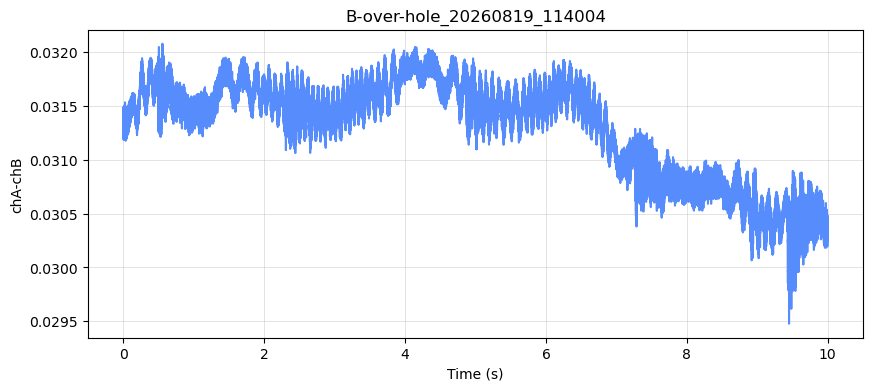

B-over-hole_20260819_114004.csv RMS = 0.45705624289852703


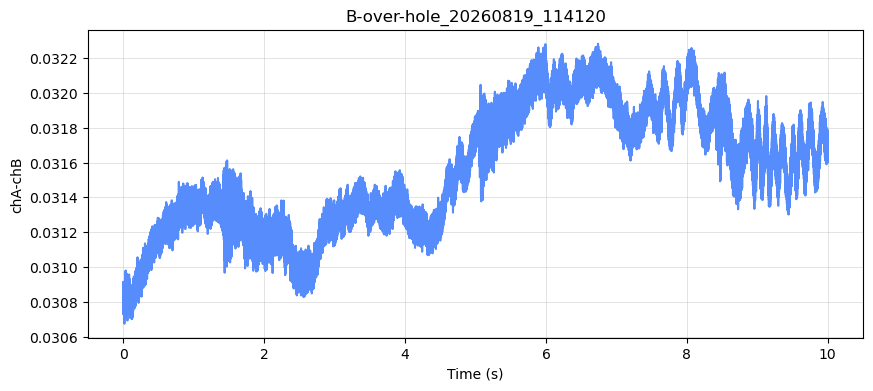

B-over-hole_20260819_114120.csv RMS = 0.3533906216435059


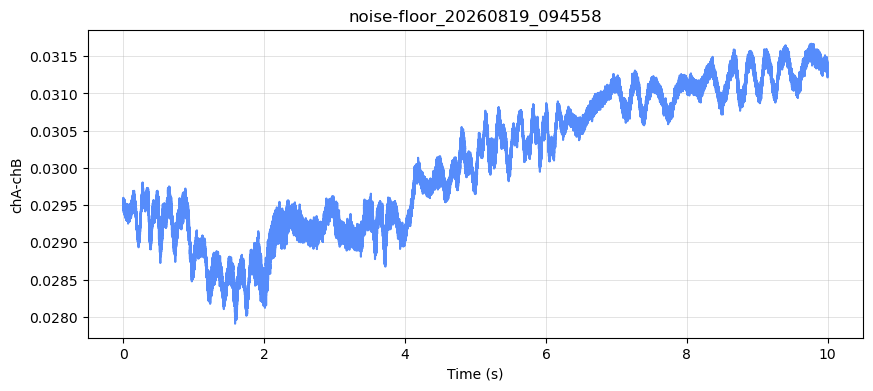

noise-floor_20260819_094558.csv RMS = 0.9395795860437369


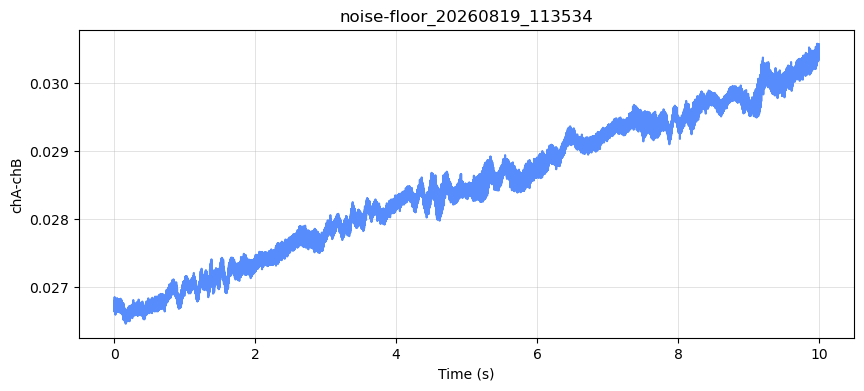

noise-floor_20260819_113534.csv RMS = 1.0503910042383966


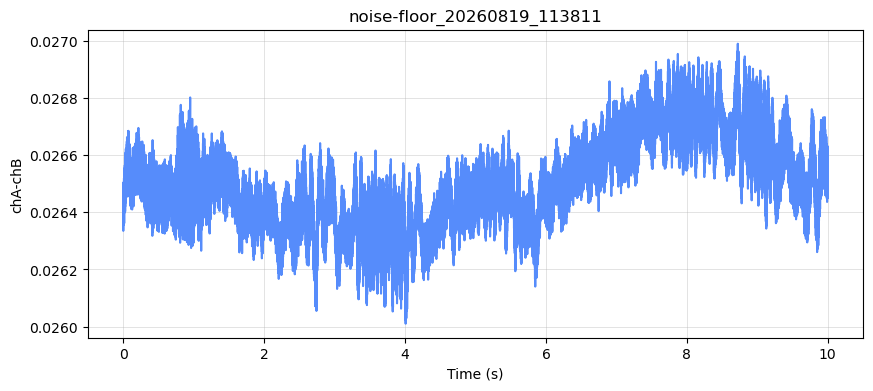

noise-floor_20260819_113811.csv RMS = 0.15055387856268965


In [9]:
for file in Path("data_to_test").glob("*.csv"):

    t, chA, chB = load_moku_csv(file)

    signal = chA+chB

    plt.figure(figsize=(10,4))

    plt.plot(t, signal)

    plt.title(file.stem)
    plt.xlabel("Time (s)")
    plt.ylabel("chA-chB")

    plt.grid()

    plt.show()

    print(
        file.name,
        "RMS =", np.std(signal)*1e3
    )

# Frequency measurement and calibration



B-over-hole_20260819_114004.csv
0.7 Hz
3.1 Hz
2.3 Hz
1.2 Hz
3.8 Hz
4.2 Hz
5.5 Hz
5.2 Hz
6.1 Hz
4.6 Hz


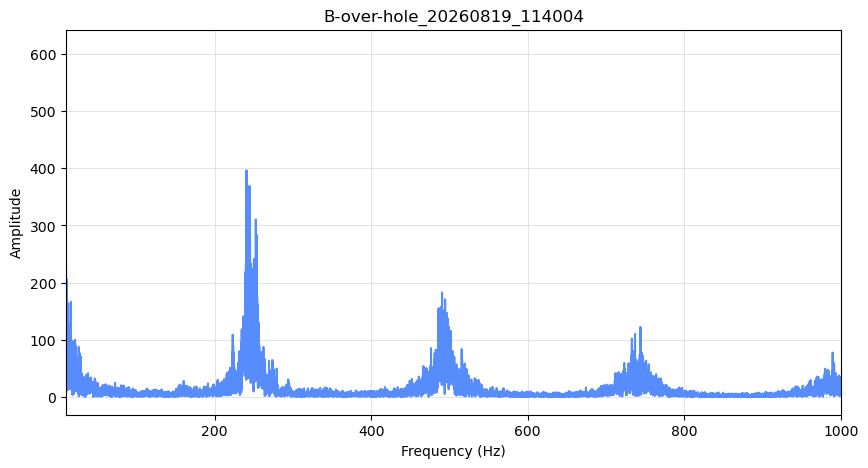



B-over-hole_20260819_114120.csv
0.2 Hz
0.5 Hz
2.8 Hz
1.2 Hz
4.8 Hz
3.4 Hz
4.2 Hz
1.5 Hz
5.1 Hz
1.8 Hz


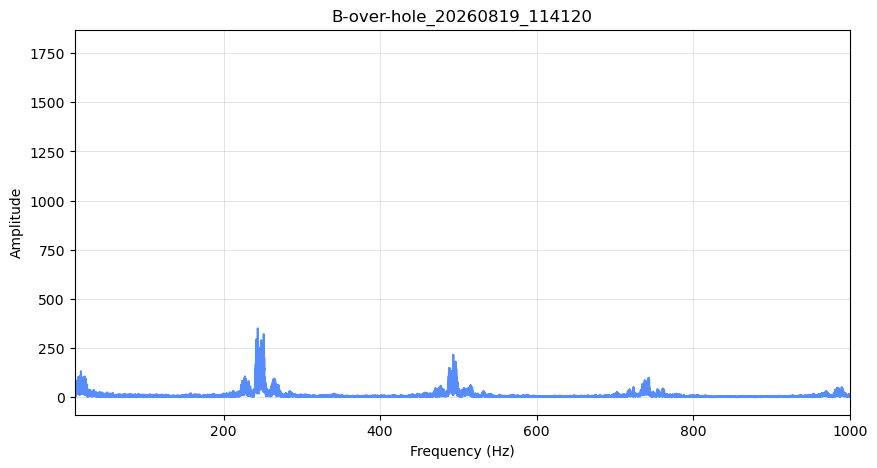



noise-floor_20260819_094558.csv
3.7 Hz
1.6 Hz
2.9 Hz
1.0 Hz
4.2 Hz
4.0 Hz
4.7 Hz
5.1 Hz
1.3 Hz
3.2 Hz


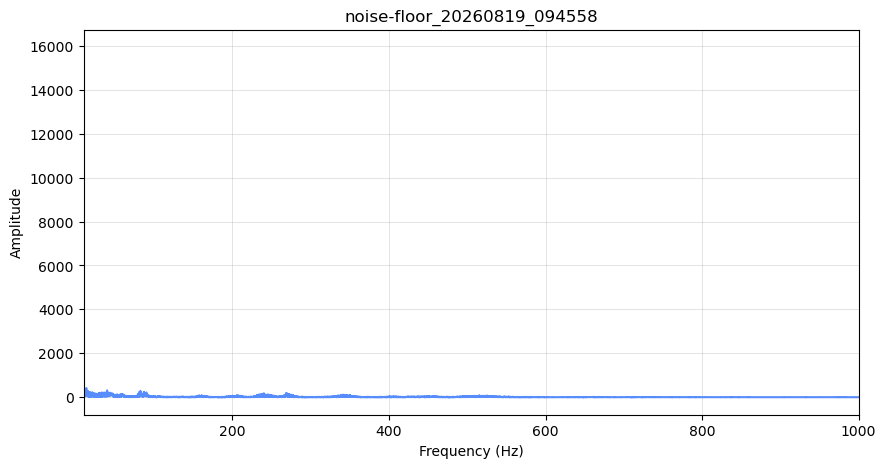



noise-floor_20260819_113534.csv
0.9 Hz
0.5 Hz
0.3 Hz
4.3 Hz
3.0 Hz
2.1 Hz
1.4 Hz
3.5 Hz
2.5 Hz
4.6 Hz


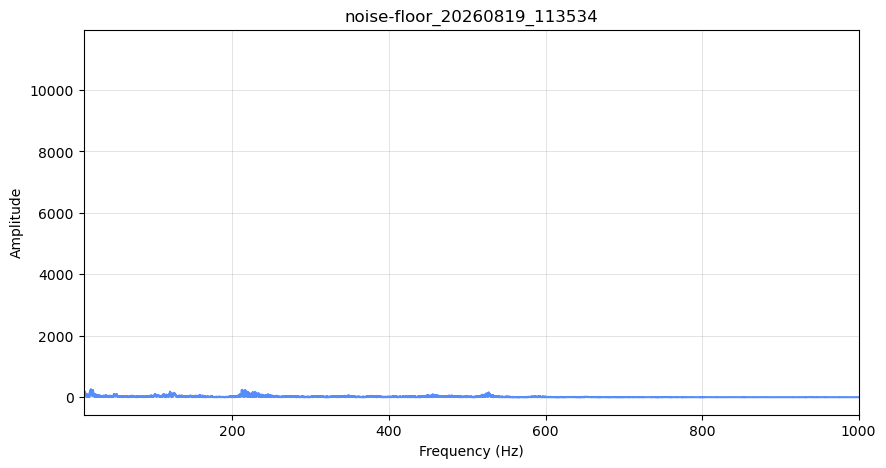



noise-floor_20260819_113811.csv
7.7 Hz
3.0 Hz
3.5 Hz
3.9 Hz
5.5 Hz
3.7 Hz
5.2 Hz
5.0 Hz
6.7 Hz
2.4 Hz


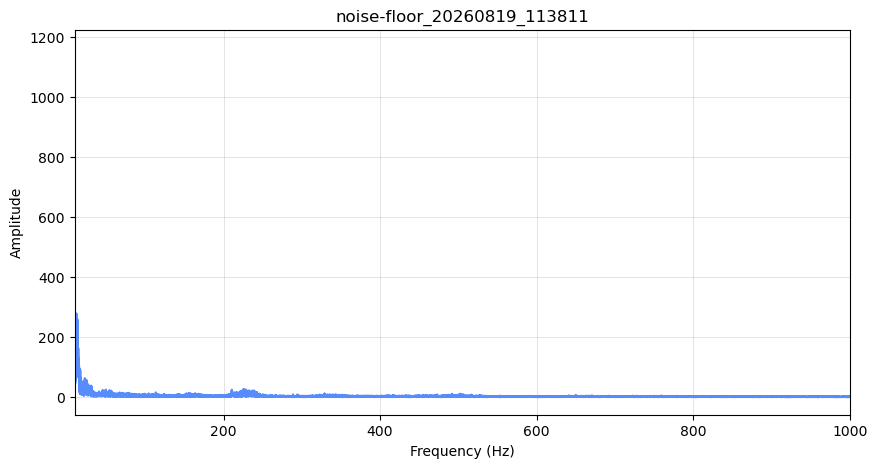

In [7]:
for file in Path("data_to_test").glob("*.csv"):

    t, chA, chB = load_moku_csv(file)

    signal = balanced_signal(chA, chB)

    fs, freqs, amp = compute_fft(t, signal)

    peaks, props = find_peaks(
        amp,
        prominence=0.05*np.max(amp)
    )

    order = np.argsort(amp[peaks])[::-1]

    print("\n")
    print(file.name)

    for idx in order[:10]:

        print(
            f"{freqs[peaks[idx]]:.1f} Hz"
        )

    plt.figure(figsize=(10,5))

    plt.plot(freqs, amp)

    plt.xlim(10,1000)

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")

    plt.title(file.stem)

    plt.grid()

    plt.show()


# Spectrogram

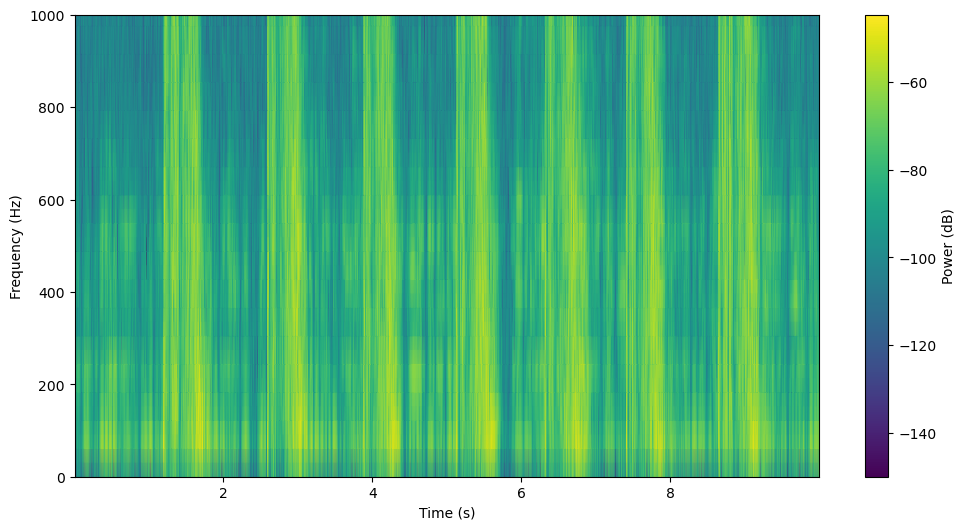

In [8]:
t, chA, chB = load_moku_csv("data/fibre-pluck_20260819_112120.csv")

signal = balanced_signal(chA, chB)

fs = 1/np.median(np.diff(t))

f, t_spec, Sxx = spectrogram(
    signal,
    fs=fs,
    nperseg=1024,
    noverlap=768
)

plt.figure(figsize=(12,6))

plt.pcolormesh(
    t_spec,
    f,
    10*np.log10(Sxx+1e-15),
    shading="gouraud"
)

plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")

plt.ylim(0,1000)

plt.colorbar(label="Power (dB)")

plt.show()